# K-Means Exercise

1. Implement K-Means++ initialization: instead of picking random centroids, pick the first randomly and each subsequent centroid with probability proportional to its squared distance from the nearest existing centroid . Compare convergence speed to random initialization.
2. Add hierarchical agglomerative clustering to the code. Implement Ward's linkage and produce a dendrogram (as a nested list of merges). Cut it at different levels and compare to K-Means results.
3. Build a simple anomaly detection pipeline: run DBSCAN and GMM on the same data, flag points that both methods agree are outliers (noise in DBSCAN, low probability in GMM). Measure the overlap and discuss when the methods disagree.


### 1. Implement K-Means++ initialization: instead of picking random centroids, pick the first randomly and each subsequent centroid with probability proportional to its squared distance from the nearest existing centroid.

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=42
)


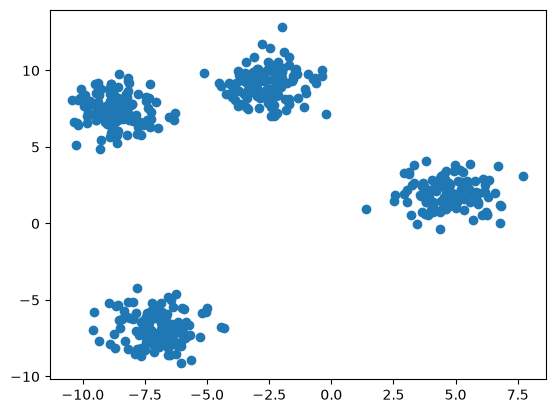

In [4]:
plt.scatter(X[:,0],X[:,1])

In [7]:
random_model=KMeans(
    n_clusters=4,
    init="random",
    n_init=1,
    random_state=42
)

plusplus_model=KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=1,
    random_state=42,
    
)

In [8]:
# fitting
random_model.fit(X)
plusplus_model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[[ 4.7

In [9]:
print("Random iterations:", random_model.n_iter_)
print("KMeans++ iterations:", plusplus_model.n_iter_)


Random iterations: 6
KMeans++ iterations: 2


**comparing convergance speed**
Random iterations: 6 
KMeans++ iterations: 2 
KMeans++ is faster then Random with more accuracy

Text(0.5, 1.0, 'Random Init')

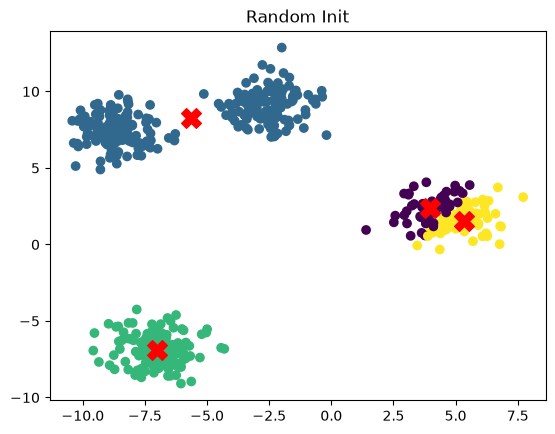

In [11]:

plt.scatter(X[:,0], X[:,1], c=random_model.labels_)
plt.scatter(random_model.cluster_centers_[:,0],
            random_model.cluster_centers_[:,1],
            c='red', s=200, marker='X')
plt.title("Random Init")



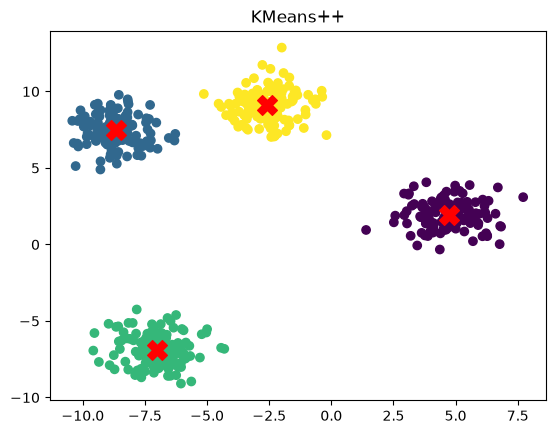

In [12]:

plt.scatter(X[:,0], X[:,1], c=plusplus_model.labels_)
plt.scatter(plusplus_model.cluster_centers_[:,0],
            plusplus_model.cluster_centers_[:,1],
            c='red', s=200, marker='X')
plt.title("KMeans++")

plt.show()

### 2. Add hierarchical agglomerative clustering to the code. Implement Ward's linkage and produce a dendrogram (as a nested list of merges). Cut it at different levels and compare to K-Means results.

Question

Build hierarchical clustering.

Need:

Ward linkage
Dendrogram
Cut tree different heights
Compare with K-Means
Ward linkage

Instead nearest distance.

Merge pair causing smallest increase in total within-cluster variance.

Goal:

Keep clusters compact.

In [13]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

X, _ = make_blobs(
    n_samples=150,
    centers=3,
    random_state=42
)


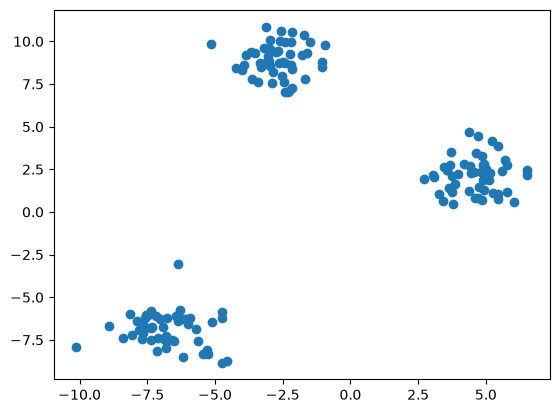

In [15]:
plt.scatter(X[:,0],X[:,1])

In [16]:
Z = linkage(X, method="ward")

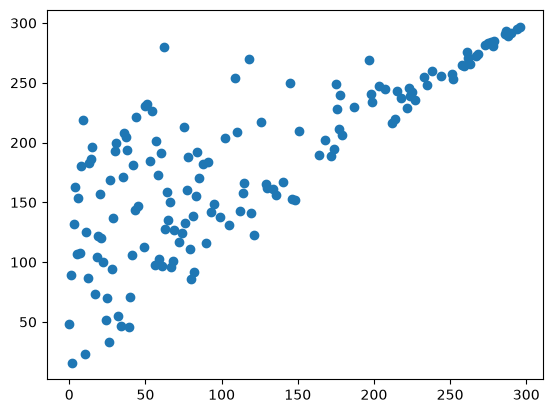

In [17]:
plt.scatter(Z[:,0],Z[:,1])


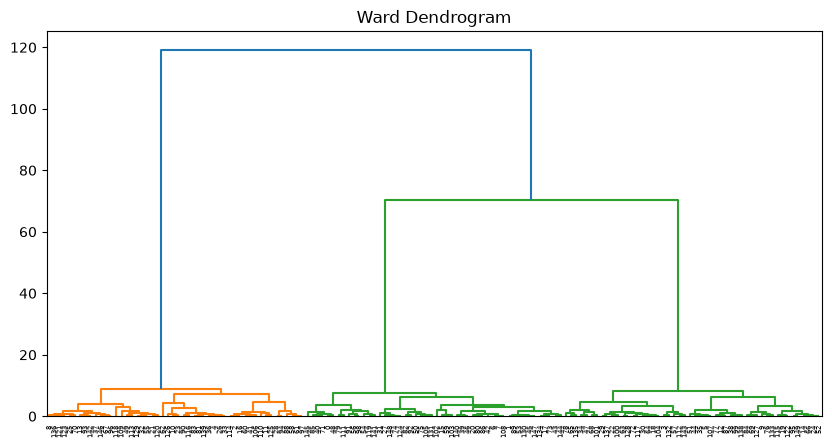

In [18]:

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Ward Dendrogram")
plt.show()


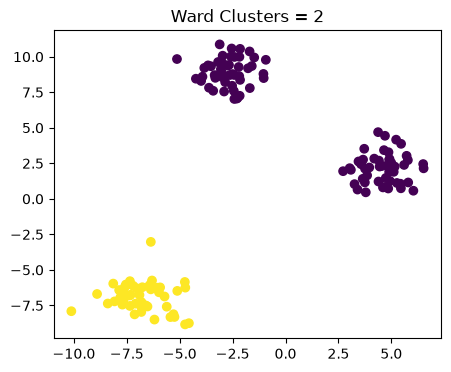

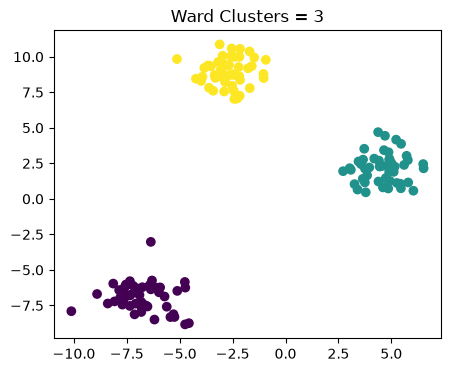

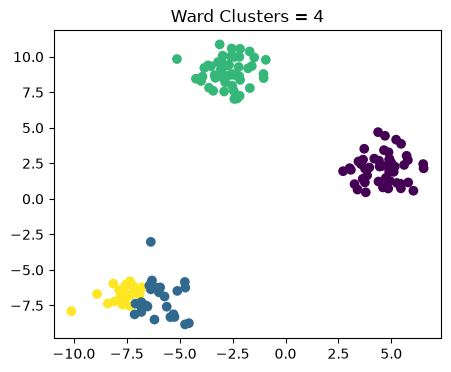

In [19]:
for k in [2,3,4]:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X)

    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.title(f"Ward Clusters = {k}")
    plt.show()

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)


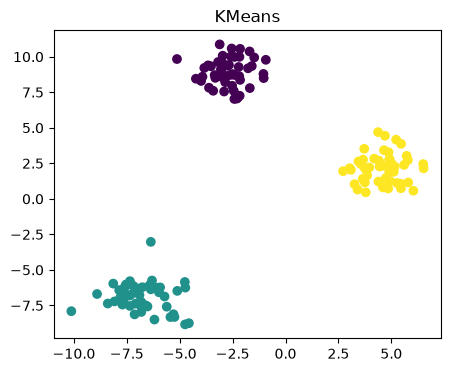

In [20]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

km_labels = kmeans.fit_predict(X)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=km_labels)
plt.title("KMeans")
plt.show()

### 3. Build a simple anomaly detection pipeline: run DBSCAN and GMM on the same data, flag points that both methods agree are outliers (noise in DBSCAN, low probability in GMM). Measure the overlap and discuss when the methods disagree.

In [21]:
import numpy as np
import matplotlib.pyplot as plt


In [23]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

In [24]:
X, _ = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

noise = np.random.uniform(
    low=-10,
    high=10,
    size=(40,2)
)


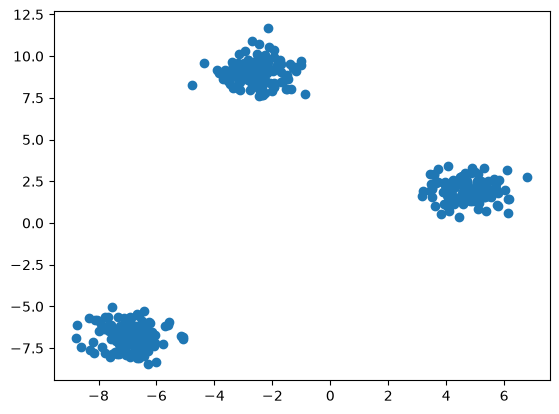

In [25]:
plt.scatter(X[:,0],X[:,1])


In [26]:
X = np.vstack([X, noise])

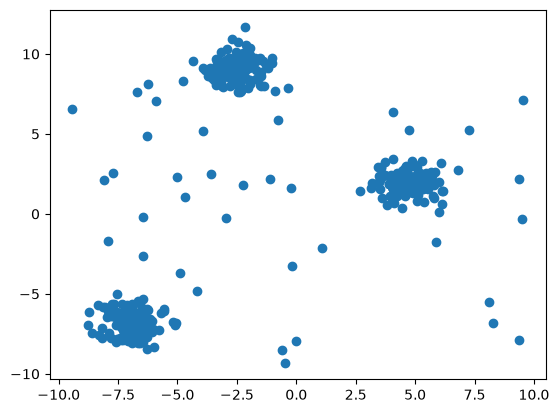

In [27]:
plt.scatter(X[:,0],X[:,1])


In [28]:
dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

In [30]:
db_labels=dbscan.fit_predict(X)

In [31]:
db_outliers=db_labels==-1

In [33]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [34]:
log_prob=gmm.score_samples(X)

In [35]:
threshold=np.percentile(log_prob,5)

In [36]:
gmm_outliers=log_prob<threshold

In [38]:
both = db_outliers & gmm_outliers

In [39]:
print("DBSCAN outliers:", db_outliers.sum())
print("GMM outliers:", gmm_outliers.sum())
print("Both agree:", both.sum())


DBSCAN outliers: 49
GMM outliers: 22
Both agree: 22


In [40]:
overlap = both.sum() / max(1, (db_outliers | gmm_outliers).sum())
print("Overlap:", overlap)


Overlap: 0.4489795918367347


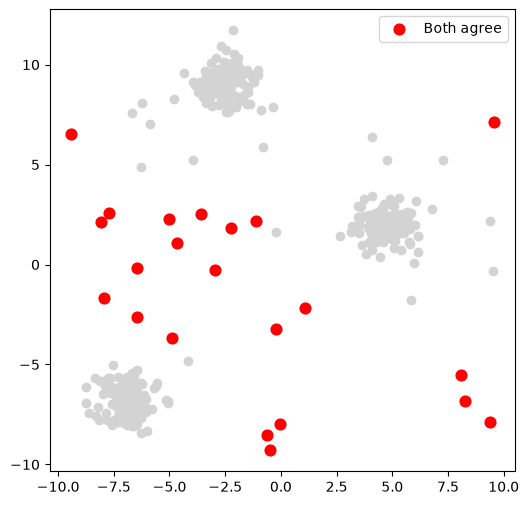

In [41]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c="lightgray")
plt.scatter(
    X[both,0],
    X[both,1],
    c="red",
    s=60,
    label="Both agree"
)

plt.legend()
plt.show()

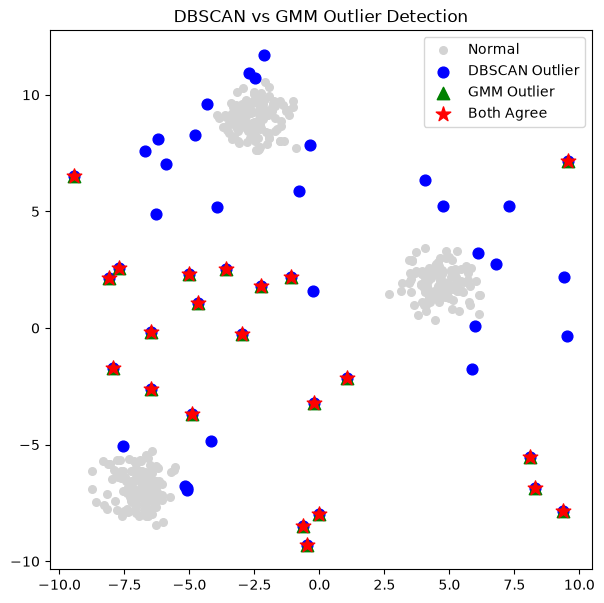

In [42]:
plt.figure(figsize=(7,7))

# Normal points
plt.scatter(
    X[:,0],
    X[:,1],
    c="lightgray",
    s=30,
    label="Normal"
)

# DBSCAN outliers
plt.scatter(
    X[db_outliers,0],
    X[db_outliers,1],
    c="blue",
    s=60,
    marker="o",
    label="DBSCAN Outlier"
)

# GMM outliers
plt.scatter(
    X[gmm_outliers,0],
    X[gmm_outliers,1],
    c="green",
    s=80,
    marker="^",
    label="GMM Outlier"
)

# Both agree
plt.scatter(
    X[both,0],
    X[both,1],
    c="red",
    s=120,
    marker="*",
    label="Both Agree"
)

plt.title("DBSCAN vs GMM Outlier Detection")
plt.legend()
plt.show()